In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('D:/Leandro/OpenFast/proyecto_IEA/Python/python-toolbox-main')

from pyFAST.input_output import FASTOutputFile

Se cargan los datos de las simulaciones de Diciembre 2023

In [45]:
folder = 'D:/Leandro/OpenFast/proyecto_IEA/corridas/09-10-2023/'
model = 'flexible'  # flexible; rigid
v = '12.0'          # velocidad [6.0:0.5:15.0]
s = '0.1'           # shear (0.1, 0.2, 0.3)
TI = '5'            # TI (5, 10, 15)
d = '000'           # x00, x en [-4:1:4]
start = 1           # índice a partir del cual se considera la serie temporal

filename = 'IEA-3.4-130-RWT_' + model + '_v' + v + '_s' + s + '_TI' + TI + '_d' + d
file = model + '/' + 'v' + v + '/' + 's' + s + '/' + 'TI' + TI + '/' + 'd' + d + '/' + filename + '.outb'

dic2023 = {}

df = FASTOutputFile(folder + file).toDataFrame()
dic2023['time'] = np.array(list(df['Time_[s]']))

dic2023['Wind1VelX'] = np.array(list(df['Wind1VelX_[m/s]']))
dic2023['RotPwr'] = np.array(list(df['RotPwr_[kW]']))
dic2023['RotSpeed'] = np.array(list(df['RotSpeed_[rpm]']))
dic2023['BldPitch1'] = np.array(list(df['BldPitch1_[deg]']))
dic2023['BldPitch2'] = np.array(list(df['BldPitch2_[deg]']))

# dic2023['RootMxb1'] = np.array(list(df['RootMxb1_[kN-m]']))
dic2023['RootMyb1'] = np.array(list(df['RootMyb1_[kN-m]']))
# dic2023['RootMxb2'] = np.array(list(df['RootMxb2_[kN-m]']))
# dic2023['RootMyb1'] = np.array(list(df['RootMyb2_[kN-m]']))
# dic2023['RootMxb3'] = np.array(list(df['RootMxb3_[kN-m]']))
# dic2023['RootMyb3'] = np.array(list(df['RootMyb3_[kN-m]']))
# dic2023['LSSGagMya'] = np.array(list(df['LSSGagMya_[kN-m]']))
# dic2023['LSSGagMza'] = np.array(list(df['LSSGagMza_[kN-m]']))
# dic2023['TwrBsMxt'] = np.array(list(df['TwrBsMxt_[kN-m]']))
# dic2023['TwrBsMyt'] = np.array(list(df['TwrBsMyt_[kN-m]']))

Se cargan los datos de las correcciones individuales de las simulaciones de diciembre 2023 (hechas en abril 2024)

In [ ]:
# No es necesario ejecutar si esta variable ya está definida
comp = {}           # "comp" de comparaciones

In [47]:
folder = 'D:/Leandro/OpenFast/proyecto_IEA/corridas/WTsimsOpenFAST_(cluster)/Comparaciones_UTE_Diciembre2023/'
case = 'a-SerieCompleta'   # al 12/04/2024, son tres casos posibles: a-SerieCompleta, b-SeedFija, c-CondIni_corregidas
v = '12'                        # velocidad [6:1:15]
shear = '0.1'                   # shear (0.1)
TI = '5'                        # TI (5)
d = '000'                       # x00, x en [0]
seed = '0'                      # seed [0,1] -> depende del case. a y c -> '0', b -> '1'

filename = 'IEA-3.4-130-RWT_' + case[0] + '_v' + v + '_shear' + shear + '_TI' + TI + '_d' + d + '_seed' + seed
file = case + '/' + 'v' + v + '/' + 'shear' + shear + '/' + 'TI' + TI + '/' + 'd' + d + '/' + 'seed' + seed + '/' + filename + '.outb'

comp[case[0]] = {}

df = FASTOutputFile(folder + file).toDataFrame()
comp[case[0]]['time'] = np.array(list(df['Time_[s]']))

comp[case[0]]['Wind1VelX'] = np.array(list(df['Wind1VelX_[m/s]']))
comp[case[0]]['RotPwr'] = np.array(list(df['RotPwr_[kW]']))
comp[case[0]]['RotSpeed'] = np.array(list(df['RotSpeed_[rpm]']))
comp[case[0]]['BldPitch1'] = np.array(list(df['BldPitch1_[deg]']))
comp[case[0]]['BldPitch2'] = np.array(list(df['BldPitch2_[deg]']))

# comp[case[0]]['RootMxb1'] = np.array(list(df['RootMxb1_[kN-m]']))
comp[case[0]]['RootMyb1'] = np.array(list(df['RootMyb1_[kN-m]']))
# comp[case[0]]['RootMxb2'] = np.array(list(df['RootMxb2_[kN-m]']))
# comp[case[0]]['RootMyb1'] = np.array(list(df['RootMyb2_[kN-m]']))
# comp[case[0]]['RootMxb3'] = np.array(list(df['RootMxb3_[kN-m]']))
# comp[case[0]]['RootMyb3'] = np.array(list(df['RootMyb3_[kN-m]']))
# comp[case[0]]['LSSGagMya'] = np.array(list(df['LSSGagMya_[kN-m]']))
# comp[case[0]]['LSSGagMza'] = np.array(list(df['LSSGagMza_[kN-m]']))
# comp[case[0]]['TwrBsMxt'] = np.array(list(df['TwrBsMxt_[kN-m]']))
# comp[case[0]]['TwrBsMyt'] = np.array(list(df['TwrBsMyt_[kN-m]']))

Se verifica que el array de tiempos sea el mismo en ambos casos

In [34]:
if comp[case[0]]['time'].shape == dic2023['time'].shape and (comp[case[0]]['time'] == dic2023['time']).all():
    time = dic2023['time']
else:
    print("Los tiempos no son iguales.\n")    

Los tiempos no son iguales.



La siguiente celda debedería ejecutarse solamente en el caso *a*, cuando la serie temporal de Dic2023 es más corta que la serie temporal del nuevo caso en estudio.

In [35]:
time = dic2023['time']

Se realiza el gráfico de las series temporales

Text(0.5, 1.0, 'Wind1VelX - v12_shear0.1_TI5_d000')

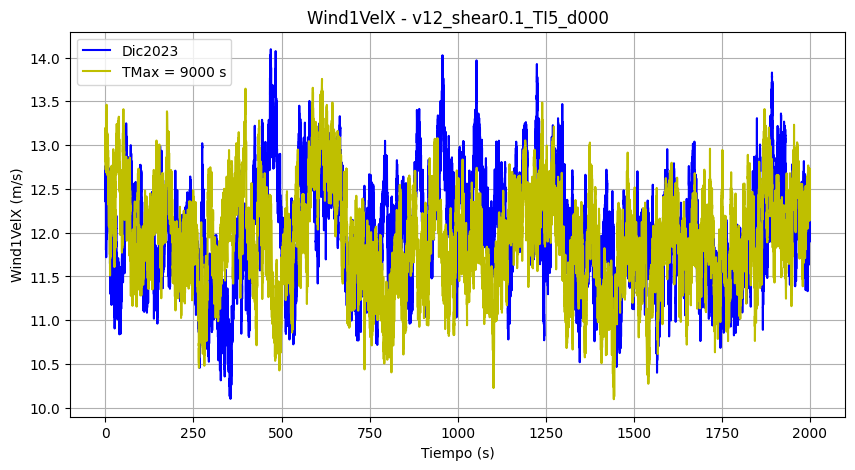

In [48]:
var = 'Wind1VelX'
unidad = 'm/s'
begin = 0
end = 200000 + 1     # 200000 es el total

plt.figure(figsize=(10, 5))
plt.plot(time[begin:end], dic2023[var][begin:end], 'b', label='Dic2023')
plt.plot(time[begin:end], comp['a'][var][begin:end], 'y', label='TMax = 9000 s')
# plt.plot(time[begin:end], comp['b'][var][begin:end], 'm', label='seed = 1')
# plt.plot(time[begin:end], comp['c'][var][begin:end], 'g', label='CI corregidas')
plt.grid()
plt.legend()
plt.xlabel('Tiempo (s)')
plt.ylabel(var + ' (' + unidad + ')')
plt.title(var + ' - v' + v + '_shear' + shear + '_TI' + TI + '_d' + d)